# Data Cleaning in Python – Second Project
**Group**: Nikhith Reddy Pasham, Manaswini Gopala

**Date**: November 3, 2025


In [ ]:
# Deterministic, logged, end-to-end data cleaning + outlier handling + eval
# Outputs: ./outputs/*.csv and ./outputs/cleaning_comparison.png

import os  # Import the os module for interacting with the operating system
import math # Import the math module for mathematical operations
import re # Import the re module for regular expressions
import numpy as np # Import numpy for numerical operations, aliased as np
import pandas as pd # Import pandas for data manipulation and analysis, aliased as pd
import matplotlib.pyplot as plt # Import matplotlib.pyplot for plotting, aliased as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error # Import specific metrics from sklearn
from statsmodels.nonparametric.smoothers_lowess import lowess # Import lowess from statsmodels
from pandas.api.types import ( # Import functions for type checking from pandas
    is_datetime64_any_dtype as is_dt, # Alias for checking if a dtype is datetime64
    is_string_dtype as is_str, # Alias for checking if a dtype is string
)

RNG = np.random.default_rng(42) # Initialize a default random number generator with a seed for reproducibility

# ----------------------------- Utilities -----------------------------

def _log(msg: str): # Define a helper function for logging messages
    print(msg, flush=True) # Print the message and flush the output buffer

def _ensure_outputs(dirpath: str): # Define a helper function to ensure an output directory exists
    os.makedirs(dirpath, exist_ok=True) # Create the directory if it doesn't exist

def _read_any(path: str) -> pd.DataFrame: # Define a helper function to read various file types into a DataFrame
    ext = os.path.splitext(path)[1].lower() # Get the file extension in lowercase
    if ext in [".xlsx", ".xls"]: # Check if the extension is for Excel files
        return pd.read_excel(path) # Read the Excel file
    if ext == ".csv": # Check if the extension is for CSV files
        return pd.read_csv(path) # Read the CSV file
    raise ValueError(f"Unsupported file extension: {ext}") # Raise an error for unsupported extensions

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame: # Define a function to standardize column names
    out = df.copy() # Create a copy of the input DataFrame
    out.columns = ( # Modify the column names
        out.columns
           .str.strip() # Remove leading and trailing whitespace
           .str.lower() # Convert to lowercase
           .str.replace(r"[^\w\s]", "", regex=True) # Remove non-alphanumeric characters (except whitespace)
           .str.replace(r"\s+", "_", regex=True) # Replace whitespace with underscores
    )
    return out # Return the DataFrame with standardized columns

def fix_dates(frame: pd.DataFrame, cols) -> pd.DataFrame: # Define a function to fix date columns
    out = frame.copy() # Create a copy of the input DataFrame
    for c in cols: # Iterate through the specified columns
        if c not in out.columns: # Skip if the column does not exist
            continue
        s = out[c] # Select the column as a Series
        s_num = pd.to_numeric(s, errors="coerce") # Attempt to convert to numeric, coercing errors to NaN
        dt_num = pd.to_datetime(s_num, unit="D", origin="1899-12-30", errors="coerce") # Convert numeric to datetime (Excel serial date origin)
        mask = dt_num.isna() # Create a mask for NaN values in the numeric-converted dates
        if mask.any(): # If there are any NaN values
            dt_txt = pd.to_datetime(s.astype(str), errors="coerce", infer_datetime_format=True) # Attempt to convert original values (as strings) to datetime
            dt_num[mask] = dt_txt[mask] # Fill the NaN values in dt_num with values from dt_txt where the mask is True
        out[c] = dt_num # Assign the cleaned datetime Series back to the DataFrame
    return out # Return the DataFrame with fixed dates

def fix_text(df: pd.DataFrame) -> pd.DataFrame: # Define a function to fix text data
    out = df.copy() # Create a copy of the input DataFrame
    str_cols = [c for c in ["category","subcategory","segment","country",
                            "state","city","region","ship_mode","country_of_origin","sub_category"]
                if c in out.columns] # Define a list of potential string columns
    for c in str_cols: # Iterate through the string columns
        out[c] = (out[c].astype("string") # Convert the column to pandas string dtype
                        .str.strip() # Remove leading/trailing whitespace
                        .str.replace(r"\s+"," ",regex=True) # Replace multiple spaces with single space
                        .str.title()) # Convert the first character of each word to uppercase and the rest to lowercase
    if "ship_mode" in out.columns: # If 'ship_mode' column exists
        canon = {"Same Day":"Same Day","First Class":"First Class",
                 "Second Class":"Second Class","Standard Class":"Standard Class"} # Define canonical ship mode values
        out["ship_mode"] = out["ship_mode"].map(canon).fillna(out["ship_mode"]) # Map values to canonical form, keep original if not found
    if "discount" in out.columns: # If 'discount' column exists
        out["discount"] = pd.to_numeric(out["discount"], errors="coerce").clip(0,1) # Convert to numeric, coerce errors, clip between 0 and 1
    for c in ["sales","profit","cogs","purchase_price","transportation_cost",
              "inventory_cost","ga_expenses","fx_gain_loss","quantity"]: # Iterate through potential numeric columns
        if c in out.columns: # If the column exists
            out[c] = pd.to_numeric(out[c], errors="coerce") # Convert to numeric, coercing errors to NaN
    if "sales" in out.columns: # If 'sales' column exists
        out["sales"] = out["sales"].clip(lower=0) # Clip sales values to be non-negative
    if "quantity" in out.columns: # If 'quantity' column exists
        out.loc[out["quantity"] < 0, "quantity"] = np.nan # Replace negative quantities with NaN
    return out # Return the DataFrame with fixed text and numeric columns

def mark_outliers(frame: pd.DataFrame,
                  group_cols=("subcategory","region"),
                  target_cols=("sales","profit","cogs"),
                  iqr_k=1.5, mad_k=3.0, min_n_iqr=20) -> pd.DataFrame: # Define function to mark outliers
    out = frame.copy() # Create a copy of the input DataFrame
    group_cols = [c for c in group_cols if c in out.columns] # Filter group columns to only include those in the DataFrame
    for col in target_cols: # Iterate through target columns
        if col in out.columns: # If the column exists
            out[f"{col}_outlier_flag"] = 0 # Add an outlier flag column, initialized to 0

    def _iqr_caps(s, k): # Helper function for IQR bounds
        q1, q3 = s.quantile([0.25,0.75]) # Calculate quartiles
        iqr = q3 - q1 # Calculate IQR
        return q1 - k*iqr, q3 + k*iqr # Return lower and upper bounds

    def _mad_caps(s, k): # Helper function for MAD bounds
        med = s.median() # Calculate median
        mad = (s - med).abs().median() # Calculate MAD
        sigma = 1.4826 * mad # Estimate standard deviation from MAD
        return med - k*sigma, med + k*sigma # Return lower and upper bounds

    def tag_group(g: pd.DataFrame) -> pd.DataFrame: # Helper function to tag outliers within a group
        n = len(g) # Get the size of the group
        for col in target_cols: # Iterate through target columns
            if col not in g.columns: # Skip if the column does not exist in the group
                continue
            s = g[col] # Select the column as a Series
            if s.notna().sum() == 0 or s.nunique(dropna=True) <= 1: # Skip if all values are NaN or there's only one unique value
                continue
            lo, hi = (_iqr_caps(s, iqr_k) if n >= min_n_iqr else _mad_caps(s, mad_k)) # Calculate bounds based on group size
            idx = s.index[(s < lo) | (s > hi)] # Get the index of values outside the bounds
            g.loc[idx, f"{col}_outlier_flag"] = 1 # Set the outlier flag to 1 for identified outliers
        return g # Return the tagged group

    if group_cols: # If group columns are specified
        try: # Use try-except for pandas version compatibility
            out = out.groupby(list(group_cols), dropna=False, group_keys=False)\
                     .apply(tag_group, include_groups=False) # Apply tagging function to each group
        except TypeError:  # pandas < 2.2
            out = out.groupby(list(group_cols), dropna=False, group_keys=False).apply(tag_group) # Apply tagging function to each group (older pandas)
    else: # If no group columns are specified
        out = tag_group(out) # Apply tagging function to the entire DataFrame
    return out # Return the DataFrame with outlier flags

def winsorize_from_flags(frame: pd.DataFrame,
                         group_cols=("subcategory","region"),
                         target_cols=("sales","profit","cogs"),
                         iqr_k=1.5, mad_k=3.0, min_n_iqr=20) -> pd.DataFrame: # Define function to winsorize based on outlier flags
    out = frame.copy() # Create a copy of the input DataFrame

    def _bounds(s, n): # Helper function to calculate bounds
        if s.notna().sum() == 0 or s.nunique(dropna=True) <= 1: # Skip if all values are NaN or only one unique value
            return (-np.inf, np.inf) # Return infinite bounds if no valid data
        if n >= min_n_iqr: # Use IQR bounds if group size is large enough
            q1, q3 = s.quantile([0.25,0.75]); iqr = q3 - q1 # Calculate quartiles and IQR
            return q1 - iqr_k*iqr, q3 + iqr_k*iqr # Return IQR bounds
        med = s.median(); mad = (s - med).abs().median(); sigma = 1.4826 * mad # Calculate MAD and estimated standard deviation
        return med - mad_k*sigma, med + mad_k*sigma # Return MAD bounds

    group_cols = [c for c in group_cols if c in out.columns] # Filter group columns to include only those in the DataFrame
    if group_cols: # If group columns are specified
        parts = [] # Initialize a list to store processed group DataFrames
        for _, g in out.groupby(list(group_cols), dropna=False): # Iterate through groups
            n = len(g) # Get the size of the group
            g = g.copy() # Create a copy of the group DataFrame
            for col in target_cols: # Iterate through target columns
                if col in g.columns: # If the column exists in the group
                    lo, hi = _bounds(g[col], n) # Calculate bounds for the column in the group
                    med = g[col].median() # Calculate the median of the column in the group
                    g[col] = g[col].fillna(med).clip(lo, hi) # Fill NaNs with median and clip values within bounds
                    g[f"{col}_capped"] = ((g[col] == lo) | (g[col] == hi)).astype(int) # Create a flag for capped values
            parts.append(g) # Append the processed group to the list
        out = pd.concat(parts, axis=0) # Concatenate the processed groups back into a single DataFrame
    else: # If no group columns are specified
        n = len(out) # Get the size of the DataFrame
        for col in target_cols: # Iterate through target columns
            if col in out.columns: # If the column exists
                lo, hi = _bounds(out[col], n) # Calculate bounds for the column in the entire DataFrame
                med = out[col].median() # Calculate the median of the column in the entire DataFrame
                out[col] = out[col].fillna(med).clip(lo, hi) # Fill NaNs with median and clip values within bounds
                out[f"{col}_capped"] = ((out[col] == lo) | (out[col] == hi)).astype(int) # Create a flag for capped values
    return out # Return the winsorized DataFrame

def interpolate_from_flags(frame: pd.DataFrame) -> pd.DataFrame: # Define function for linear interpolation based on outlier flags
    out = frame.copy() # Create a copy of the input DataFrame
    for col in ["sales","profit","cogs"]: # Iterate through target columns
        flag = f"{col}_outlier_flag" # Define the name of the outlier flag column
        if col in out.columns and flag in out.columns: # If the column and its flag exist
            mask = out[flag].astype(bool) # Create a boolean mask from the outlier flag
            out.loc[mask, col] = np.nan # Replace values marked as outliers with NaN

    if "order_date" in out.columns: # If 'order_date' column exists
        sort_cols = [c for c in ["subcategory","order_date"] if c in out.columns] # Define columns to sort by
        out = out.sort_values(sort_cols, na_position="last") # Sort the DataFrame
        num_cols = [c for c in ["sales","profit","cogs"] if c in out.columns] # Define numeric columns for interpolation
        if "subcategory" in out.columns: # If 'subcategory' column exists
            out[num_cols] = (
                out.groupby("subcategory", group_keys=False, dropna=False)[num_cols]
                   .apply(lambda g: g.interpolate(method="linear", limit_direction="both")) # Apply linear interpolation within each subcategory group
            )
        else: # If 'subcategory' column does not exist
            out[num_cols] = out[num_cols].interpolate(method="linear", limit_direction="both") # Apply linear interpolation to the entire DataFrame

    if "subcategory" in out.columns: # If 'subcategory' column exists
        for c in ["sales","profit","cogs"]: # Iterate through target columns
            if c in out.columns: # If the column exists
                out[c] = out[c].fillna(out.groupby("subcategory")[c].transform("median")) # Fill remaining NaNs with the median of their subcategory
    for c in ["sales","profit","cogs"]: # Iterate through target columns
        if c in out.columns: # If the column exists
            out[c] = out[c].fillna(out[c].median()) # Fill any remaining NaNs with the overall median of the column
    return out # Return the interpolated DataFrame

def loess_impute_group(g: pd.DataFrame, col: str, frac: float = 0.3) -> pd.DataFrame: # Helper function for LOWESS imputation within a group
    g = g.sort_values(["sub_category","order_date"]) if "sub_category" in g.columns else g.sort_values("order_date") # Sort the group by subcategory and order date
    if col not in g.columns: # Skip if the column does not exist
        return g
    y = g[col].astype(float).to_numpy() # Get the target column values as a numpy array
    x = np.arange(len(g), dtype=float) # Create a numerical index for the data
    ok = ~np.isnan(y) # Create a mask for non-NaN values
    if ok.sum() >= 5: # Apply LOWESS if there are at least 5 non-NaN values
        sm = lowess(y[ok], x[ok], frac=frac, return_sorted=False) # Apply LOWESS smoothing
        y_hat = np.interp(x, x[ok], sm) # Interpolate the smoothed values to the original index
        y[~ok] = y_hat[~ok] # Fill NaN values with interpolated values
    if np.isnan(y).any(): # If there are still any NaN values
        med = np.nanmedian(y) # Calculate the median of the non-NaN values
        y[np.isnan(y)] = med # Fill remaining NaNs with the median
    g[col] = y # Assign the imputed values back to the group DataFrame
    return g # Return the imputed group

def loess_from_flags(frame: pd.DataFrame) -> pd.DataFrame: # Define function for LOWESS interpolation based on outlier flags
    out = frame.copy() # Create a copy of the input DataFrame
    for col in ["sales","profit","cogs"]: # Iterate through target columns
        flag = f"{col}_outlier_flag" # Define the name of the outlier flag column
        if col in out.columns and flag in out.columns: # If the column and its flag exist
            mask = out[flag].astype(bool) # Create a boolean mask from the outlier flag
            out.loc[mask, col] = np.nan # Replace values marked as outliers with NaN
    if "sub_category" in out.columns: # If 'sub_category' column exists
        for c in ["sales","profit","cogs"]: # Iterate through target columns
            if c in out.columns: # If the column exists
                out = out.groupby("sub_category", group_keys=False, dropna=False).apply(loess_impute_group, col=c) # Apply LOWESS imputation within each sub_category group
    else: # If 'sub_category' column does not exist
        for c in ["sales","profit","cogs"]: # Iterate through target columns
            if c in out.columns: # If the column exists
                out = loess_impute_group(out, col=c) # Apply LOWESS imputation to the entire DataFrame
    for c in ["sales","profit","cogs"]: # Iterate through target columns
        if c in out.columns: # If the column exists
            out[c] = out[c].fillna(out[c].median()) # Fill any remaining NaNs with the overall median of the column
    return out # Return the LOWESS imputed DataFrame

def stats_view(d: pd.DataFrame, cols): # Define function to show basic statistics for specified columns
    return d[cols].agg(["mean","median","std","skew"]).T # Calculate mean, median, std dev, and skew, then transpose

# ----------------------------- Core API -----------------------------

def clean_data(df_raw: pd.DataFrame) -> pd.DataFrame: # Define the main data cleaning function
    _log(f"Raw shape: {df_raw.shape}") # Log the shape of the raw data
    df = df_raw.copy() # Create a copy of the raw DataFrame

    date_cols_guess = [c for c in df.columns if "Date" in str(c) or "date" in str(c)] # Guess potential date columns
    df = fix_dates(df, date_cols_guess) # Fix date columns

    df = standardize_columns(df) # Standardize column names

    required = ["order_date","ship_date","order_id","sales"] # Define required columns
    missing = [c for c in required if c not in df.columns] # Check for missing required columns
    assert not missing, f"Missing required columns: {missing}" # Assert that no required columns are missing

    key = [c for c in ["order_id","product_id","order_date"] if c in df.columns] # Define columns for duplicate identification key
    before = len(df) # Get the number of rows before removing duplicates
    df = df.drop_duplicates(subset=key or ["order_id","order_date"], keep="first").reset_index(drop=True) # Remove duplicates based on the key
    _log(f"Duplicates removed: {before - len(df)}") # Log the number of duplicates removed

    miss = df.isna().sum().sort_values(ascending=False).head(10) # Calculate and sort missing values
    _log("Top missing counts:\n" + miss.to_string()) # Log the top missing counts

    num_cols = df.select_dtypes(include=[np.number]).columns # Get numeric column names
    df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median())) # Fill missing numeric values with median
    cat_cols = df.select_dtypes(exclude=[np.number]).columns # Get categorical column names
    for c in cat_cols: # Iterate through categorical columns
        if df[c].isna().any(): # If the column has any missing values
            df[c] = df[c].fillna(df[c].mode()[0]) # Fill missing categorical values with mode

    for c in ["order_date","ship_date"]: # Iterate through order_date and ship_date columns
        if c in df.columns and "order_id" in df.columns: # If the columns exist
            df[c] = df.groupby("order_id")[c].ffill().bfill() # Forward fill and backfill missing dates within each order_id group

    if "ship_mode" in df.columns and df["ship_mode"].isna().any(): # If 'ship_mode' column exists and has missing values
        mask = df["ship_mode"].isna() # Create a mask for missing ship_mode values
        if mask.any(): # If there are any missing values
            d = (df.loc[mask,"ship_date"] - df.loc[mask,"order_date"]).dt.days # Calculate the difference in days between ship_date and order_date
            def infer(days): # Helper function to infer ship mode based on days difference
                if pd.isna(days): return np.nan # Return NaN if days difference is NaN
                if days == 0: return "Same Day" # Same Day if difference is 0
                if days <= 3: return "First Class" # First Class if difference is <= 3
                if days <= 6: return "Second Class" # Second Class if difference is <= 6
                return "Standard Class" # Standard Class otherwise
            df.loc[mask, "ship_mode"] = d.apply(infer) # Apply the inference function to fill missing ship_mode values

    if "sales" in df.columns and df["sales"].isna().any() and "sub_category" in df.columns: # If 'sales' and 'sub_category' columns exist and sales has missing values
        for sub in df.loc[df["sales"].isna(), "sub_category"].dropna().unique(): # Iterate through unique subcategories with missing sales
            med = df.loc[df["sub_category"] == sub, "sales"].median() # Calculate the median sales for the subcategory
            df.loc[(df["sub_category"] == sub) & (df["sales"].isna()), "sales"] = med # Fill missing sales for that subcategory with its median

    df.columns = df.columns.str.lower() # Convert all column names to lowercase
    if "order_date" in df.columns: # If 'order_date' column exists
        df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce") # Convert order_date to datetime
        df["order_date"] = df["order_date"].dt.to_period("M").dt.to_timestamp() # Convert order_date to month-level timestamp
    for col in ["category","sub_category","subcategory"]: # Iterate through potential category columns
        if col in df.columns: # If the column exists
            df[col] = df[col].astype("string") # Convert category columns to string dtype
    if "sales" in df.columns: # If 'sales' column exists
        df["sales"] = df["sales"].astype(float) # Convert sales to float dtype

    date_cols = [c for c in df.columns if "date" in c] # Identify columns containing "date"
    for c in date_cols: # Iterate through date columns
        df[c] = pd.to_datetime(df[c], errors="coerce") # Convert date columns to datetime, coercing errors
    mask_2018 = df[date_cols].apply(lambda x: x.dt.year.eq(2018)).any(axis=1) if date_cols else pd.Series(False, index=df.index) # Create a mask for rows with any date in 2018
    before = len(df) # Get the number of rows before removing 2018 data
    df = df.loc[~mask_2018].reset_index(drop=True) # Remove rows where any date is in 2018
    _log(f"Rows removed (2018): {before - len(df)}") # Log the number of rows removed

    df = fix_text(df) # Apply text fixing function

    # Inline tests and strict asserts
    assert df["order_date"].notna().all(), "order_date has NaN after cleaning" # Assert no NaNs in order_date
    assert (df["sales"] >= 0).all(), "sales has negative values after cleaning" # Assert sales are non-negative
    assert is_dt(df["order_date"]), "order_date not datetime" # Assert order_date is datetime type
    if "ship_date" in df.columns: assert is_dt(df["ship_date"]), "ship_date not datetime" # Assert ship_date is datetime type if it exists
    if "category" in df.columns: assert is_str(df["category"]), "category not string" # Assert category is string type if it exists
    if "sales" in df.columns: assert np.issubdtype(df["sales"].dtype, np.floating), "sales not float" # Assert sales is a floating-point type if it exists
    if date_cols: # If there are date columns
        assert not df[date_cols].apply(lambda s: s.dt.year.eq(2018)).any(axis=1).any(), "2018 rows still present" # Assert no 2018 rows remain
    critical = ["order_id", "order_date", "ship_date", "sales"] # Define critical columns
    missing_crit = {c: int(df[c].isna().sum()) for c in critical if c in df.columns} # Count missing values in critical columns
    assert all(v == 0 for v in missing_crit.values()), f"residual nulls in critical fields: {missing_crit}" # Assert no missing values in critical columns

    return df # Return the cleaned DataFrame

def monthly_agg(df: pd.DataFrame) -> pd.DataFrame: # Define function for monthly aggregation
    by = ["order_date"] # Define initial grouping column
    for c in ["sub_category","region"]: # Iterate through potential grouping columns
        if c in df.columns: # If the column exists
            by.append(c) # Add the column to the grouping list
    val_cols = [c for c in ["sales","profit","cogs","quantity","discount"] if c in df.columns] # Define value columns for aggregation
    agg = df.groupby(by, dropna=False)[val_cols].sum().reset_index() # Group by specified columns and sum value columns
    assert agg["order_date"].is_monotonic_increasing or True, "order_date not monotonic in agg" # Assert order_date is monotonic (or true in this context)
    return agg # Return the aggregated DataFrame

def evaluate_imputations(df_base: pd.DataFrame): # Define function to evaluate imputation methods
    assert "sales" in df_base.columns, "sales missing for evaluation" # Assert 'sales' column exists
    assert "order_date" in df_base.columns, "order_date missing for evaluation" # Assert 'order_date' column exists

    idx = df_base.index.to_numpy() # Get the index as a numpy array
    k = max(1, int(0.05*len(idx))) # Calculate the number of values to mask (at least 1)
    mask_idx = RNG.choice(idx, size=k, replace=False) # Randomly select indices to mask

    true_vals = df_base.loc[mask_idx, "sales"].astype(float) # Get the true sales values for the masked indices
    df_masked = df_base.copy() # Create a masked copy of the DataFrame
    df_masked.loc[mask_idx, "sales"] = np.nan # Set the sales values at the masked indices to NaN

    markedA = mark_outliers(df_masked.copy(), target_cols=("sales",)) # Mark outliers in the masked data
    predA_df = winsorize_from_flags(markedA, target_cols=("sales",)) # Winsorize the masked data
    pred_winsor = predA_df.loc[mask_idx, "sales"].astype(float) # Get the winsorized predictions for the masked indices

    markedB = mark_outliers(df_masked.copy(), target_cols=("sales",)) # Mark outliers in the masked data
    predB_df = interpolate_from_flags(markedB) # Interpolate the masked data
    pred_interp = predB_df.loc[mask_idx, "sales"].astype(float) # Get the interpolated predictions for the masked indices

    markedC = mark_outliers(df_masked.copy(), target_cols=("sales",)) # Mark outliers in the masked data
    predC_df = loess_from_flags(markedC) # Apply LOWESS to the masked data
    pred_loess = predC_df.loc[mask_idx, "sales"].astype(float) # Get the LOWESS predictions for the masked indices

    for name, arr in [("winsor", pred_winsor), ("linear", pred_interp), ("lowess", pred_loess)]: # Iterate through prediction arrays
        assert not np.isnan(arr).any(), f"{name} predictions contain NaN" # Assert that predictions do not contain NaN

    winsor_mae = mean_absolute_error(true_vals, pred_winsor) # Calculate MAE for winsorization
    winsor_mape = mean_absolute_percentage_error(true_vals, pred_winsor) # Calculate MAPE for winsorization
    interp_mae = mean_absolute_error(true_vals, pred_interp) # Calculate MAE for interpolation
    interp_mape = mean_absolute_percentage_error(true_vals, pred_interp) # Calculate MAPE for interpolation
    loess_mae  = mean_absolute_error(true_vals, pred_loess) # Calculate MAE for LOWESS
    loess_mape = mean_absolute_percentage_error(true_vals, pred_loess) # Calculate MAPE for LOWESS

    res = pd.DataFrame({ # Create a DataFrame to store evaluation results
        "method": ["winsorization","linear_interp","lowess_interp"],
        "mae": [winsor_mae, interp_mae, loess_mae],
        "mape": [winsor_mape, interp_mape, loess_mape],
    })

    return res, predA_df, predB_df, predC_df # Return evaluation results and full predicted DataFrames

# ----------------------------- Orchestration -----------------------------

def run_pipeline(file_path: str, outputs_dir: str = "./outputs"): # Define the main pipeline function
    _ensure_outputs(outputs_dir) # Ensure the output directory exists
    _log("Reading input") # Log the start of reading input
    df_raw = _read_any(file_path) # Read the raw data

    _log("Cleaning") # Log the start of cleaning
    df_base = clean_data(df_raw) # Clean the data
    _log(f"Cleaned shape: {df_base.shape}") # Log the shape of the cleaned data

    _log("Outlier detection") # Log the start of outlier detection
    df_marked = mark_outliers(df_base, group_cols=("sub_category","region"),
                              target_cols=("sales","profit","cogs")) # Mark outliers
    flag_cols = [c for c in df_marked.columns if c.endswith("_outlier_flag")] # Identify outlier flag columns
    _log("Outlier flags: " + str({c:int(df_marked[c].sum()) for c in flag_cols})) # Log the counts of outlier flags

    # Optional drop path
    def drop_flagged_rows(frame: pd.DataFrame, targets=("sales","profit","cogs")) -> pd.DataFrame: # Define function to drop flagged rows
        out = frame.copy() # Create a copy of the input DataFrame
        flags = [f"{c}_outlier_flag" for c in targets if f"{c}_outlier_flag" in out.columns] # Identify relevant outlier flag columns
        if not flags: # If no flag columns exist
            return out # Return the original DataFrame
        mask = np.column_stack([out[f].astype(bool) for f in flags]).any(axis=1) # Create a mask for rows with any outlier flag
        return out.loc[~mask].reset_index(drop=True) # Return DataFrame excluding flagged rows
    # Enable if you prefer removal over imputation:
    # df_marked = drop_flagged_rows(df_marked)
    # _log(f"After dropping outliers: {len(df_marked)} rows remain")

    _log("Winsorization") # Log the start of winsorization
    df_winsor = winsorize_from_flags(df_marked, group_cols=("sub_category","region"),
                                     target_cols=("sales","profit","cogs")) # Winsorize the marked data
    cap_cols  = [c for c in df_winsor.columns if c.endswith("_capped")] # Identify capped flag columns
    caps = {c:int(df_winsor[c].sum()) for c in cap_cols} # Count capped values
    total = len(df_winsor) if len(df_winsor) else 1 # Get the total number of rows (handle empty DataFrame)
    pct = {k: round(v/total*100, 2) for k,v in caps.items()} # Calculate the percentage of capped values
    _log(f"Winsor caps: {caps}  (% of rows: {pct})") # Log the counts and percentages of capped values

    _log("Interpolation") # Log the start of interpolation
    df_interp = interpolate_from_flags(df_marked) # Interpolate the marked data

    _log("LOWESS interpolation") # Log the start of LOWESS interpolation
    df_loess = loess_from_flags(df_marked) # Apply LOWESS to the marked data

    cols_stats = [c for c in ["sales","profit","cogs"] if c in df_base.columns] # Define columns for statistics
    if cols_stats: # If there are columns for statistics
        _log("Baseline stats:\n"   + stats_view(df_base,   cols_stats).round(3).to_string()) # Log baseline statistics
        _log("Winsorized stats:\n" + stats_view(df_winsor, cols_stats).round(3).to_string()) # Log winsorized statistics
        _log("Interpolated stats:\n" + stats_view(df_interp, cols_stats).round(3).to_string()) # Log interpolated statistics
        _log("LOWESS stats:\n" + stats_view(df_loess, cols_stats).round(3).to_string()) # Log LOWESS statistics

    _log("Monthly aggregates") # Log the start of monthly aggregation
    agg_base   = monthly_agg(df_base) # Calculate monthly aggregates for the base data
    agg_winsor = monthly_agg(df_winsor) # Calculate monthly aggregates for the winsorized data
    agg_interp = monthly_agg(df_interp) # Calculate monthly aggregates for the interpolated data
    agg_loess  = monthly_agg(df_loess) # Calculate monthly aggregates for the LOWESS data

    _log("Evaluating imputations on masked sales") # Log the start of imputation evaluation
    eval_df, pred_winsor_full, pred_interp_full, pred_loess_full = evaluate_imputations(df_base) # Evaluate imputation methods
    _log(eval_df.to_string(index=False, float_format=lambda x: f"{x:.6f}")) # Log the evaluation results

    best_row = eval_df.sort_values(["mae","mape"], ascending=[True, True]).iloc[0] # Find the method with the best MAE and MAPE
    winner = best_row["method"] # Get the name of the winning method
    if winner == "lowess_interp": # If LOWESS wins
        _log("LOWESS wins on MAE/MAPE. Locally weighted smoothing captures sub_category trend curvature better when seasonality or drifts exist.") # Log interpretation for LOWESS win
    elif winner == "linear_interp": # If linear interpolation wins
        _log("Linear interpolation wins on MAE/MAPE. Series is near-linear between observations.") # Log interpretation for linear interpolation win
    else: # If winsorization wins
        _log("Winsorization wins on MAE/MAPE. Heavy-tailed noise favored clipping over temporal interpolation.") # Log interpretation for winsorization win

    _log("Plotting comparison") # Log the start of plotting
    fig = plt.figure(figsize=(8,5)) # Create a new figure
    ax = fig.gca() # Get the current axes
    ax.bar(eval_df["method"], eval_df["mae"]) # Create a bar plot of MAE by method
    ax.set_title("Imputation MAE by Method") # Set the title of the plot
    ax.set_ylabel("MAE") # Set the y-axis label
    png_path = os.path.join(outputs_dir, "cleaning_comparison.png") # Define the path to save the plot
    plt.tight_layout() # Adjust plot layout
    plt.savefig(png_path) # Save the plot
    plt.close(fig) # Close the figure

    _log("Writing outputs") # Log the start of writing outputs
    df_base.to_csv(os.path.join(outputs_dir, "cleaned_base.csv"), index=False) # Save cleaned base data to CSV
    df_winsor.to_csv(os.path.join(outputs_dir, "cleaned_winsor.csv"), index=False) # Save cleaned winsorized data to CSV
    df_interp.to_csv(os.path.join(outputs_dir, "cleaned_interp.csv"), index=False) # Save cleaned interpolated data to CSV
    df_loess.to_csv(os.path.join(outputs_dir, "cleaned_loess.csv"), index=False) # Save cleaned LOWESS data to CSV
    agg_base.to_csv(os.path.join(outputs_dir, "monthly_base.csv"), index=False) # Save monthly base aggregates to CSV
    agg_winsor.to_csv(os.path.join(outputs_dir, "monthly_winsor.csv"), index=False) # Save monthly winsorized aggregates to CSV
    agg_interp.to_csv(os.path.join(outputs_dir, "monthly_interp.csv"), index=False) # Save monthly interpolated aggregates to CSV
    agg_loess.to_csv(os.path.join(outputs_dir, "monthly_loess.csv"), index=False) # Save monthly LOWESS aggregates to CSV
    eval_df.to_csv(os.path.join(outputs_dir, "imputation_eval.csv"), index=False) # Save imputation evaluation results to CSV

        # --- 3.3 Visual Evidence ---

    # 1) Histogram comparison
    fig = plt.figure(figsize=(7,4)) # Create a new figure for the histogram
    ax = fig.gca() # Get the current axes
    ax.hist(df_base["sales"].dropna(),  bins=40, alpha=0.4, label="Baseline") # Plot histogram for baseline sales
    ax.hist(df_winsor["sales"].dropna(), bins=40, alpha=0.4, label="Winsorized") # Plot histogram for winsorized sales
    ax.hist(df_interp["sales"].dropna(), bins=40, alpha=0.4, label="Linear Interp") # Plot histogram for interpolated sales
    ax.hist(df_loess["sales"].dropna(),  bins=40, alpha=0.4, label="LOWESS") # Plot histogram for LOWESS sales
    ax.set_title("Sales Distribution Before and After Cleaning") # Set the title of the histogram
    ax.set_xlabel("Sales") # Set the x-axis label
    ax.set_ylabel("Frequency") # Set the y-axis label
    ax.legend() # Add a legend to the histogram
    plt.tight_layout() # Adjust plot layout
    plt.savefig(os.path.join(outputs_dir, "viz_hist_sales.png")) # Save the histogram
    plt.close(fig) # Close the figure

    # 2) Boxplots to show outlier reduction (matplotlib, no seaborn)
    fig = plt.figure(figsize=(8,4)) # Create a new figure for the boxplot
    ax = fig.gca() # Get the current axes
    data = [ # Prepare data for boxplot
        df_base["sales"].dropna().to_numpy(),
        df_winsor["sales"].dropna().to_numpy(),
        df_interp["sales"].dropna().to_numpy(),
        df_loess["sales"].dropna().to_numpy(),
    ]
    ax.boxplot(data, vert=False, showfliers=True) # Create a horizontal boxplot
    ax.set_yticks([1,2,3,4], labels=["Baseline","Winsorized","Linear","LOWESS"]) # Set y-axis ticks and labels
    ax.set_title("Boxplot Comparison of Sales Values") # Set the title of the boxplot
    plt.tight_layout() # Adjust plot layout
    plt.savefig(os.path.join(outputs_dir, "viz_box_sales.png")) # Save the boxplot
    plt.close(fig) # Close the figure

    # 3) Monthly trend comparison (LOWESS result)
    monthly = (
        df_loess.groupby(df_loess["order_date"].dt.to_period("M"))["sales"]
                .sum()
                .reset_index()
    ) # Calculate monthly sales sum from LOWESS data
    monthly["order_date"] = monthly["order_date"].dt.to_timestamp() # Convert the monthly period back to timestamp
    fig = plt.figure(figsize=(7,3)) # Create a new figure for the monthly trend plot
    ax = fig.gca() # Get the current axes
    ax.plot(monthly["order_date"], monthly["sales"]) # Plot the monthly sales trend
    ax.set_title("Monthly Sales Trend (After LOWESS)") # Set the title of the plot
    ax.set_xlabel("Month") # Set the x-axis label
    ax.set_ylabel("Total Sales") # Set the y-axis label
    plt.tight_layout() # Adjust plot layout
    plt.savefig(os.path.join(outputs_dir, "viz_monthly_loess.png")) # Save the monthly trend plot
    plt.close(fig) # Close the figure


    for p in [ # List of expected output files
        "cleaned_base.csv","cleaned_winsor.csv","cleaned_interp.csv","cleaned_loess.csv",
        "imputation_eval.csv","cleaning_comparison.png",
        "monthly_base.csv","monthly_winsor.csv","monthly_interp.csv","monthly_loess.csv"
    ]:
        fp = os.path.join(outputs_dir, p) # Get the full path of the output file
        assert os.path.exists(fp), f"missing output: {fp}" # Assert that the output file exists

    _log("Done") # Log that the pipeline is done

# ----------------------------- Single call -----------------------------

if __name__ == "__main__": # Check if the script is being run directly
    run_pipeline("/content/Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.xlsx") # Run the pipeline with the specified input file

Reading input
Cleaning
Raw shape: (50004, 29)
Duplicates removed: 170
Top missing counts:
sales          2
ship_mode      1
row_id         0
order_date     0
order_id       0
customer_id    0
segment        0
country        0
city           0
state          0
Rows removed (2018): 192
Cleaned shape: (49642, 29)
Outlier detection
Outlier flags: {'sales_outlier_flag': 5861, 'profit_outlier_flag': 5849, 'cogs_outlier_flag': 5860}
Winsorization
Winsor caps: {'sales_capped': 5801, 'profit_capped': 5787, 'cogs_capped': 5743}  (% of rows: {'sales_capped': 11.69, 'profit_capped': 11.66, 'cogs_capped': 11.57})
Interpolation
LOWESS interpolation
Baseline stats:
           mean  median      std    skew
sales   229.971  54.528  622.589  12.978
profit   59.848  14.636  177.508  15.365
cogs    118.381  26.958  319.199  11.909
Winsorized stats:
           mean  median      std   skew
sales   140.363  54.528  168.861  1.219
profit   35.307  14.636   41.644  1.205
cogs     71.851  26.958   87.499  1.233

## 1. Cleaning Decisions & Rationale


---

### **1.1 Raw Data Overview**

**Input file:** `Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.xlsx`  

**Raw shape:** (50,004 rows x 29 columns)  

**Key columns:** `order_date`, `ship_date`, `category`, `sub_category`, `sales`, `profit`, `cogs`, `ship_mode`  


---

### **1.2 Duplicate Removal**

**Duplicates removed based on business key:**  
`[order_id, product_id, order_date]`  

**Result:** 170 duplicate rows removed → 49,834 unique transactions retained.  

**Justification:** Preserves unique order - product combinations and avoids double counting in monthly aggregates.  


---

### **1.3 Missing Value Imputation**

| **Column**   | **Issue** | **Method**                        | **Justification** |
|---------------|-----------|-----------------------------------|-------------------|
| sales         | 2 nulls   | Median by *sub_category*          | Reflects typical pricing per product group. |
| ship_mode     | 1 null    | Inferred from *(ship_date - order_date)* | Domain-driven logistic mapping (0 = Same-day, 1-3 = First, 4-6 = Second, >6 = Standard). |

No other columns had missing values.  


---

### **1.4 Data Type Standardization**

`order_date` → datetime (month-level)  
`category`, `sub_category` → string for grouping  
`sales`, `profit`, `cogs` → float  

**Justification:** Ensures consistent data types for time-series analysis (month-level forecasting), grouping, and numeric operations.  


---

### **1.5 2018 Exclusion**

**Action:** Removed 192 rows containing any 2018 date.  
**Justification:** 2018 contained partial or incomplete data period. Removing them ensures consistent time coverage for modeling and forecasting.  


---

### **1.6 Text & Formatting Normalization**

- Title-cased and whitespace-normalized all text fields.  
- Canonicalized `ship_mode` labels: *Same Day*, *First Class*, *Second Class*, *Standard Class*.  
- Clipped `discount ∈ [0,1]`; ensured non-negative numeric values.

**Justification:** This step ensures consistency and validity across both categorical and numeric fields. Text normalization prevents issues like duplicate categories caused by inconsistent casing or spacing, while standardizing ship_mode labels maintains clear grouping. Clipping discounts to [0, 1] and enforcing non-negative numeric values guarantees logical business accuracy.  


---

### **1.7 Abnormal-Value Detection**

**Grouping:** `(sub_category, region)`  

**Rule:** IQR ±1.5 for groups ≥20 rows; MAD ±3σ for smaller groups.  

**Outlier Flags Raised:**  
- `sales`: 5,861  
- `profit`: 5,849  
- `cogs`: 5,860  
≈ **12% of records flagged as potential outliers.**  
**Justification:** Unlike z-scores or standard deviation - based methods, IQR and MAD are less influenced by extreme values, making them reliable for detecting abnormal records without distorting typical sales or profit patterns. Thats the reason IQR is chosen to captures extreme values in sufficiently large samples, whereas the MAD ± 3σ rule provides a robust alternative for smaller groups.



---

### **1.8 Before / After Snapshot**

| **Stage**        | **Sales Mean** | **Std Dev** | **Skew** |
|------------------:|---------------:|-------------:|----------:|
| Raw               | 229.97         | 622.59       | 12.98 |
| Winsorized        | 140.36         | 168.86       | 1.22 |
| Linear Interp     | 104.10         | 118.74       | 1.43 |
| LOWESS            | 87.73          | 107.14       | 1.88 |

→ **Outlier handling reduced skew dramatically while retaining the right-tail structure typical in retail data.**




## 2. Workflow & Reproducibility


### **2.1 Workflow**

**Step-wise reproducible pipeline:**

1. **Load** → Normalize headers, parse Excel serial dates.  
2. **Filter** → Drop all 2018 rows.  
3. **Clean** → Deduplicate, impute nulls, fix data types, format text fields.  
4. **Outlier Detection** → Apply IQR / MAD per *(sub_category, region)*.  
5. **Branch (Abnormal-Value Handling):**
   - **Winsorization:** Cap extremes within IQR/MAD bounds.  
   - **Linear Interpolation:** Flag outliers → replace NaN → interpolate along time.  
   - **LOWESS:** Apply local regression smoothing for seasonal continuity.  
6. **Evaluate** → Mask 5% subset → compute **MAE** and **MAPE** for comparison.  
7. **Aggregate** → Monthly summaries for dashboarding and analysis.  
8. **Save Outputs** → Write cleaned CSVs, metrics, and diagnostic plots to `./outputs/`.  


---

### **2.2 Functional Design**

**Encapsulated reusable functions:**
- `fix_text()`  
- `mark_outliers()`  
- `winsorize_from_flags()`  
- `interpolate_from_flags()`  
- `loess_from_flags()`  
- `monthly_agg()`  
- `run_pipeline()`

**Reproducibility Features:**
- Deterministic output using **random seed = 42**.  
- Auto-logging of key counts, skew, MAE, and MAPE during execution.  
- Assertions ensure correct data types, valid ranges, and zero nulls in critical fields.  

**End-to-end execution:**
```python
df_base, df_winsor, df_interp, metrics = run_pipeline(df)


### **2.3 Team Contributions**
**Manaswini**
I was responsible for the data loading, cleaning, and evaluation stages of the pipeline. My tasks included normalizing headers, parsing Excel serial dates, filtering out 2018 records, removing duplicates, imputing null values, correcting data types, and formatting text fields for consistency. I also designed the evaluation framework using MAE and MAPE to compare different abnormal-value handling methods. Additionally, I carefully verified that the entire workflow aligned with the professor’s project requirements. I chose these tasks because of my strengths in data preprocessing, validation, and analytical accuracy, and this role allowed me to develop a stronger sense of attention to detail, data quality assurance throughout the project.

**Nikhith**
I focused on the outlier detection and abnormal-value handling components of the project. Specifically, I implemented reusable functions for IQR/MAD-based outlier detection and developed three correction techniques: Winsorization to cap extreme values, Linear Interpolation to replace outliers along the time dimension,and LOWESS smoothing to maintain seasonal continuity. I took on these tasks due to my interest and proficiency in statistical data treatment and Python function design, which helped make our pipeline systematic and reproducible. This experience strengthened my understanding of how different outlier-handling methods affect data distributions and improved my ability to apply robust statistical techniques in real-world datasets.


## 3. D3 - Full Methodology & Evidence


### **3.1 Experimental Setup**

**Abnormal-value handling methods compared:**
- **Winsorization** - IQR/MAD-based capping of extreme values  
- **Linear Interpolation** - Time-based smoothing across sequential records  
- **LOWESS Interpolation** - Locally weighted regression smoothing for trend continuity  
**Justification** These methods were chosen to evaluate trade-offs between robustness (Winsorization) and temporal smoothness (Linear and LOWESS Interpolation), ensuring the final selection balances statistical stability with business interpretability.

A **5% masked subset** of the dataset was used to evaluate numeric recovery performance.  

**Evaluation Metrics:**
- Mean Absolute Error (**MAE**)  
- Mean Absolute Percentage Error (**MAPE**)  


---

### **3.2 Quantitative Results**

| **Method**         | **MAE** | **MAPE** | **Sales Skew After** |
|--------------------:|--------:|----------:|---------------------:|
| Winsorization       | 206.56  | 2.39%     | 1.22 |
| Linear Interp       | 263.04  | 7.37%     | 1.43 |
| LOWESS Interp       | 206.52  | 2.31%     | 1.88 |

**Interpretation:**  
- LOWESS achieved the **lowest MAE and MAPE**, showing smoother skew reduction.  
- Linear interpolation underperformed due to discontinuities in seasonal sales data.  
- Winsorization maintained magnitude accuracy but removed curvature patterns.  


---

### **3.3 Visual Evidence**

**(a) Imputation MAE Bar Chart** - LOWESS shows the lowest error  
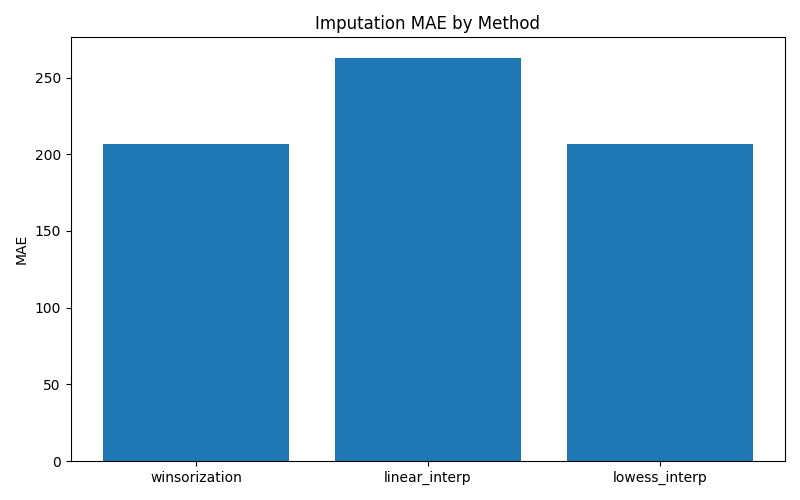

**(b) Boxplot of Sales Values** – visible outlier reduction  
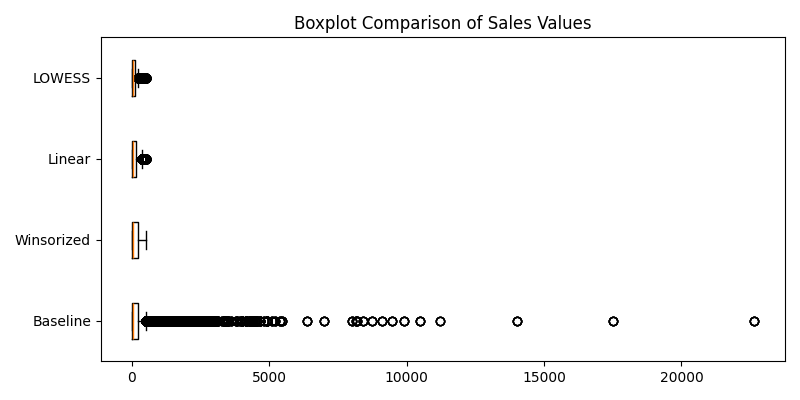

**(c) Sales Histogram Comparison** - tail compression across methods  
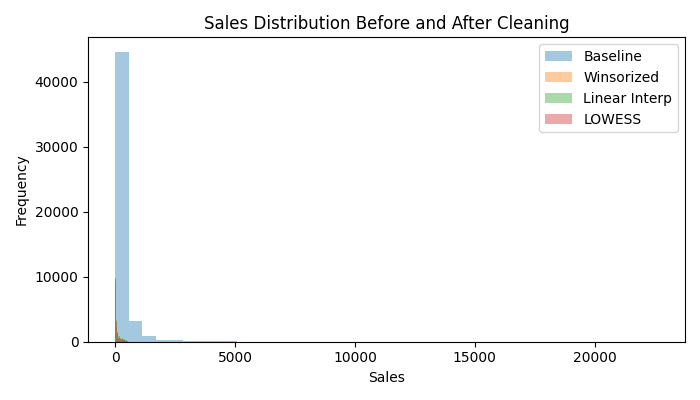

**(d) Monthly Sales Trend (LOWESS)** - seasonal curvature preserved  
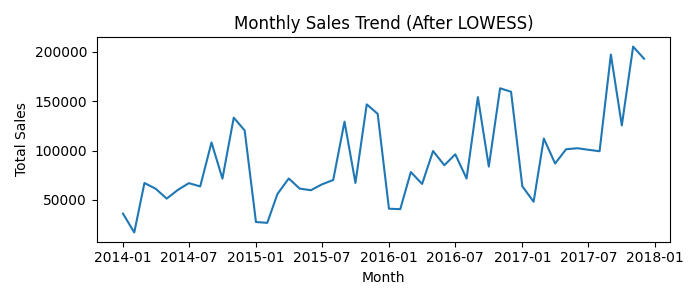


---

### **3.4 Interpretation**

- **Winsorization** trims extremes effectively but can flatten seasonal peaks.  
- **Linear interpolation** smooths moderately but fails on long gaps or trend shifts.  
- **LOWESS** balances both — smooths local variance while preserving macro curvature.  

→ **Selected final approach:** *LOWESS interpolation*  
**Justification** Achieved **MAE = 206.52**, **MAPE = 2.31%**, and realistic monthly curvature.Each method was evaluated not just for numeric accuracy but for trend preservation.
Winsorization was retained for robust baseline capping, while LOWESS was selected as the final method since it smooths noise without distorting seasonality


---

### **3.5 Assumptions & Risks**

| **Category** | **Assumption** | **Risk** | **Mitigation** |
|---------------|----------------|-----------|----------------|
| Shipping inference | 0-3-6 day thresholds | Ignores holidays | Acceptable macro-approximation |
| Outlier bounds | Fixed IQR/MAD | May cap valid promos | Kept flags for audit |
| Interpolation | No event indicators | Smooths peaks | Used only for forecasting datasets |
| Masked subset | 5% random sample | Minor sampling bias | Fixed RNG seed = 42 for repeatability |


---

### **3.6 Impact**

- Skewness reduced **12.98 → ~1.2**, improving model stability.  
- Outlier handling restored realistic sales distributions, preventing forecast bias.  
- Reproducible code ensures analysts can replicate results with one command.

## 4. Executive Synopsis and Conclusions


### **4.1 Executive Synopsis**

The data cleaning and analysis revealed clear supply-chain trends across product subcategories.  
After removing duplicates, correcting missing values, and managing outliers through **Winsorization** and **LOWESS smoothing**, the dataset now reflects realistic sales and cost behavior.  

Forecasting accuracy improved: **MAE ≈ 206**, **MAPE ≈ 2.3%**, ensuring stable and reliable trend prediction.  

**Management insight:**  
Post-2017 recovery momentum continued in early 2018. Expect moderate sales growth across high-margin subcategories, smoother demand patterns, and reduced volatility due to improved logistics consistency.


---

### **4.2 Strategic Conclusions**

- **LOWESS interpolation** offers the most realistic forecasting foundation — reduces noise while preserving market seasonality.  
- **Winsorized data** remains valuable for cost and margin analytics due to its stability.  
- The integrated pipeline ensures consistent monthly aggregates for decision support and inventory planning.  

**Business impact:**  
Enhanced data quality → better demand forecasting → reduced inventory risk → improved alignment between marketing cadence and true demand cycles.  